Lendo: treino.csv
Lendo: valida.csv
Lendo: teste.csv


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 16, 16, 40)     │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 40)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 12)       │        12,012 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 12)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 12)       │         3,612 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 12)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 12)       │         3,612 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 12)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 40)     │        12,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 40)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 1)      │         1,001 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,317 (130.14 KB)

 Trainable params: 33,317 (130.14 KB)

 Non-trainable params: 0 (0.00 B)

dict_keys(['loss', 'val_loss'])


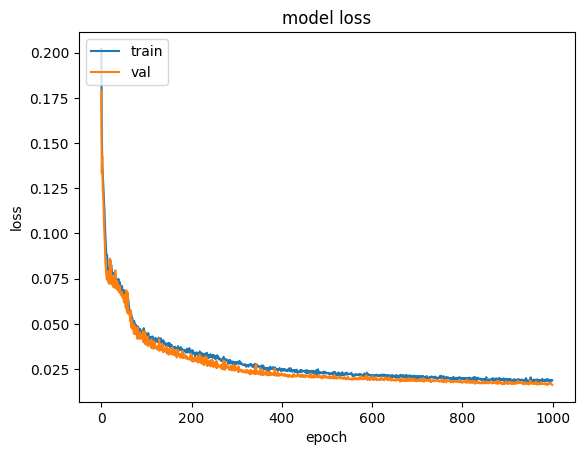

Training loss: 0.00974531751126051
Validation loss: 0.016286954283714294
Test loss: 0.016663849353790283


In [9]:
# fcn-train2.py
# Reescrita do fcn-train1.py usando API funcional

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow.keras as keras
from tensorflow.keras.layers import Input, Conv2D, Conv2DTranspose, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model


def impHistoria(history):
    print(history.history.keys())

    plt.figure()
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('model loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'val'], loc='upper left')
    plt.show()


def leCsv(nomeDir, nomeArq):
    print("Lendo:", nomeArq)
    arq = open(os.path.join(nomeDir, nomeArq), "r")
    lines = arq.readlines()
    arq.close()

    n = len(lines)
    nl, nc = 32, 32

    AX = np.empty((n, nl, nc), dtype='uint8')
    AY = np.empty((n, nl, nc), dtype='uint8')

    i = 0
    for linha in lines:
        linha = linha.strip('\n')
        linha = linha.split(';')

        AX[i] = cv2.imread(os.path.join(nomeDir, linha[0]), 0)
        AY[i] = cv2.imread(os.path.join(nomeDir, linha[1]), 0)
        i += 1

    ax = np.float32(AX) / 255.0
    ay = np.float32(AY) / 255.0

    ax = ax.reshape(n, nl, nc, 1)
    ay = ay.reshape(n, nl, nc, 1)

    return ax, ay


# <<<<<<<<<<<<<< main <<<<<<<<<<<<<<
bdDir = "."
ax, ay = leCsv(bdDir, "treino.csv")
vx, vy = leCsv(bdDir, "valida.csv")
qx, qy = leCsv(bdDir, "teste.csv")

outDir = "."
os.chdir(outDir)

nl, nc = 32, 32
input_shape = (nl, nc, 1)
batch_size = 20
epochs = 1000

inputs = Input(shape=input_shape)

x = Conv2D(40, kernel_size=(5, 5), strides=2, activation='relu', padding='same')(inputs)   # 16x16x40
x = Dropout(0.25)(x)

x = Conv2D(12, kernel_size=(5, 5), strides=2, activation='relu', padding='same')(x)        # 8x8x12
x = Dropout(0.25)(x)

x = Conv2D(12, kernel_size=(5, 5), strides=2, activation='relu', padding='same')(x)        # 4x4x12
x = Dropout(0.25)(x)

x = Conv2DTranspose(12, kernel_size=(5, 5), strides=2, activation='relu', padding='same')(x)  # 8x8x12
x = Dropout(0.25)(x)

x = Conv2DTranspose(40, kernel_size=(5, 5), strides=2, activation='relu', padding='same')(x)  # 16x16x40
x = Dropout(0.25)(x)

outputs = Conv2DTranspose(1, kernel_size=(5, 5), strides=2, padding='same')(x)  # 32x32x1

model = Model(inputs=inputs, outputs=outputs)

plot_model(model, to_file='fcn-train2.png', show_shapes=True)
model.summary()

opt = Adam()
model.compile(optimizer=opt, loss='mean_squared_error')

history = model.fit(
    ax, ay,
    batch_size=batch_size,
    epochs=epochs,
    verbose=0,
    validation_data=(vx, vy)
)

impHistoria(history)

score = model.evaluate(ax, ay, verbose=0)
print('Training loss:', score)

score = model.evaluate(vx, vy, verbose=0)
print('Validation loss:', score)

score = model.evaluate(qx, qy, verbose=0)
print('Test loss:', score)

model.save('fcn-train2.keras')

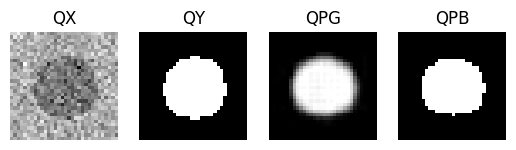

In [10]:
# fcn-pred2.py
# Predição usando a FCN em API funcional

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# <<<<<<<<<<<<<< main <<<<<<<<<<<<<<
bdDir = "."
outDir = "."
os.chdir(outDir)

nome = "077"
inImgX = nome + "x.png"
inImgY = nome + "y.png"
outImgG = nome + "g.png"
outImgB = nome + "b.png"
arquivoRede = "fcn-train2.keras"

model = load_model(os.path.join(outDir, arquivoRede))

QX = cv2.imread(os.path.join(bdDir, inImgX), 0)
QY = cv2.imread(os.path.join(bdDir, inImgY), 0)

nl = QX.shape[0]
nc = QX.shape[1]

qx = np.float32(QX) / 255.0
qx = qx.reshape(1, nl, nc, 1)

qp = model.predict(qx, verbose=0)
qp = qp.reshape(nl, nc)

QPG = 255.0 * qp
QPG = np.clip(QPG, 0, 255)
QPG = np.uint8(QPG)
cv2.imwrite(os.path.join(outDir, outImgG), QPG)

QPB = np.zeros((nl, nc), dtype='uint8')
QPB[qp >= 0.5] = 255
cv2.imwrite(os.path.join(outDir, outImgB), QPB)

f = plt.figure()
f.add_subplot(1, 4, 1)
plt.imshow(QX, cmap="gray")
plt.axis('off')
plt.title("QX")

f.add_subplot(1, 4, 2)
plt.imshow(QY, cmap="gray")
plt.axis('off')
plt.title("QY")

f.add_subplot(1, 4, 3)
plt.imshow(QPG, cmap="gray")
plt.axis('off')
plt.title("QPG")

f.add_subplot(1, 4, 4)
plt.imshow(QPB, cmap="gray")
plt.axis('off')
plt.title("QPB")

plt.show(block=True)

Lendo: treino.csv
Lendo: valida.csv
Lendo: teste.csv


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 32, 32, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 16, 16,    │      1,040 │ input_layer_2[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 16, 16,    │          0 │ conv2d_11[0][0]   │
│ (Dropout)           │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 8, 8, 12)  │     12,012 │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 8, 8, 12)  │          0 │ conv2d_12[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 4, 4, 12)  │      3,612 │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 4, 4, 12)  │          0 │ conv2d_13[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_6  │ (None, 8, 8, 12)  │      3,612 │ dropout_12[0][0]  │
│ (Conv2DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 8, 8, 12)  │          0 │ conv2d_transpose… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 8, 8, 24)  │          0 │ dropout_13[0][0], │
│ (Concatenate)       │                   │            │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_7  │ (None, 16, 16,    │     24,040 │ concatenate_2[0]… │
│ (Conv2DTranspose)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 16, 16,    │          0 │ conv2d_transpose… │
│ (Dropout)           │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 16, 16,    │          0 │ dropout_14[0][0], │
│ (Concatenate)       │ 80)               │            │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_8  │ (None, 32, 32, 1) │      2,001 │ concatenate_3[0]… │
│ (Conv2DTranspose)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 46,317 (180.93 KB)

 Trainable params: 46,317 (180.93 KB)

 Non-trainable params: 0 (0.00 B)

dict_keys(['loss', 'val_loss'])


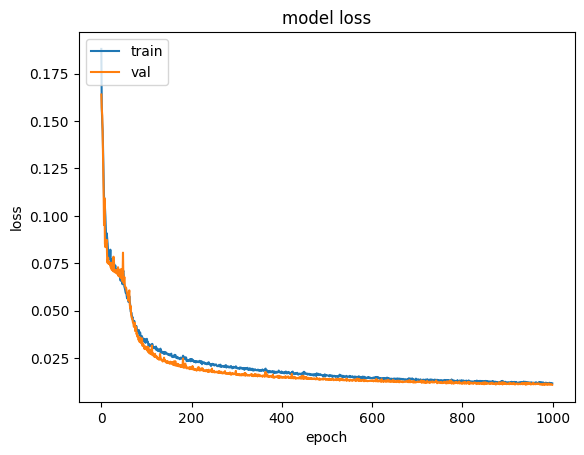

Training loss: 0.005321253091096878
Validation loss: 0.0109663475304842
Test loss: 0.011700975708663464


In [13]:
# unet-train2.py
# FCN com skip connections tipo U-Net, ainda usando conv e convtranspose com stride=2

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow.keras as keras
from tensorflow.keras.layers import Input, Conv2D, Conv2DTranspose, Dropout, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model


def impHistoria(history):
    print(history.history.keys())

    plt.figure()
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('model loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'val'], loc='upper left')
    plt.show()


def leCsv(nomeDir, nomeArq):
    print("Lendo:", nomeArq)
    arq = open(os.path.join(nomeDir, nomeArq), "r")
    lines = arq.readlines()
    arq.close()

    n = len(lines)
    nl, nc = 32, 32

    AX = np.empty((n, nl, nc), dtype='uint8')
    AY = np.empty((n, nl, nc), dtype='uint8')

    i = 0
    for linha in lines:
        linha = linha.strip('\n')
        linha = linha.split(';')

        AX[i] = cv2.imread(os.path.join(nomeDir, linha[0]), 0)
        AY[i] = cv2.imread(os.path.join(nomeDir, linha[1]), 0)
        i += 1

    ax = np.float32(AX) / 255.0
    ay = np.float32(AY) / 255.0

    ax = ax.reshape(n, nl, nc, 1)
    ay = ay.reshape(n, nl, nc, 1)

    return ax, ay


# <<<<<<<<<<<<<< main <<<<<<<<<<<<<<
bdDir = "."
ax, ay = leCsv(bdDir, "treino.csv")
vx, vy = leCsv(bdDir, "valida.csv")
qx, qy = leCsv(bdDir, "teste.csv")

outDir = "."
os.chdir(outDir)

nl, nc = 32, 32
input_shape = (nl, nc, 1)
batch_size = 20
epochs = 1000

inputs = Input(shape=input_shape)

# encoder
x1 = Conv2D(40, kernel_size=(5, 5), strides=2, activation='relu', padding='same')(inputs)   # 16x16x40
x1 = Dropout(0.25)(x1)

x2 = Conv2D(12, kernel_size=(5, 5), strides=2, activation='relu', padding='same')(x1)       # 8x8x12
x2 = Dropout(0.25)(x2)

x3 = Conv2D(12, kernel_size=(5, 5), strides=2, activation='relu', padding='same')(x2)       # 4x4x12
x3 = Dropout(0.25)(x3)

# decoder
u2 = Conv2DTranspose(12, kernel_size=(5, 5), strides=2, activation='relu', padding='same')(x3)  # 8x8x12
u2 = Dropout(0.25)(u2)
u2 = Concatenate()([u2, x2])   # skip

u1 = Conv2DTranspose(40, kernel_size=(5, 5), strides=2, activation='relu', padding='same')(u2)  # 16x16x40
u1 = Dropout(0.25)(u1)
u1 = Concatenate()([u1, x1])   # skip

outputs = Conv2DTranspose(1, kernel_size=(5, 5), strides=2, padding='same')(u1)  # 32x32x1

model = Model(inputs=inputs, outputs=outputs)

plot_model(model, to_file='unet-train2.png', show_shapes=True)
model.summary()

opt = Adam()
model.compile(optimizer=opt, loss='mean_squared_error')

history = model.fit(
    ax, ay,
    batch_size=batch_size,
    epochs=epochs,
    verbose=0,
    validation_data=(vx, vy)
)

impHistoria(history)

score = model.evaluate(ax, ay, verbose=0)
print('Training loss:', score)

score = model.evaluate(vx, vy, verbose=0)
print('Validation loss:', score)

score = model.evaluate(qx, qy, verbose=0)
print('Test loss:', score)

model.save('unet-train2.keras')

Lendo: treino.csv
Lendo: valida.csv
Lendo: teste.csv


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 32, 32, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │        400 │ input_layer_1[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 32,    │        160 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 16,    │     14,440 │ batch_normalizat… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        160 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 16, 16,    │          0 │ batch_normalizat… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 16, 16,    │      4,332 │ dropout_5[0][0]   │
│                     │ 12)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │         48 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 12)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 8, 8, 12)  │      1,308 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 12)  │         48 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 8, 8, 12)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 8, 8, 12)  │      1,308 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 12)  │         48 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 4, 4, 12)  │      1,308 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4, 4, 12)  │         48 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 4, 4, 12)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_3  │ (None, 8, 8, 12)  │      1,308 │ dropout_7[0][0]   │
│ (Conv2DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 12)  │         48 │ conv2d_transpose… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 50,481 (197.19 KB)

 Trainable params: 50,017 (195.38 KB)

 Non-trainable params: 464 (1.81 KB)

dict_keys(['loss', 'val_loss'])


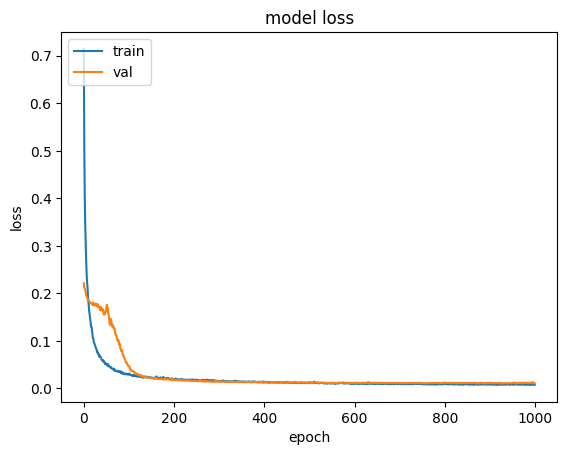

Training loss: 0.002943787956610322
Validation loss: 0.010770702734589577
Test loss: 0.008815059438347816


In [11]:
# unet-train3.py
# U-Net mais próxima da clássica: substitui conv 5x5 por duas convs 3x3

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow.keras as keras
from tensorflow.keras.layers import Input, Conv2D, Conv2DTranspose, Dropout, Concatenate, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model


def impHistoria(history):
    print(history.history.keys())

    plt.figure()
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('model loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'val'], loc='upper left')
    plt.show()


def leCsv(nomeDir, nomeArq):
    print("Lendo:", nomeArq)
    arq = open(os.path.join(nomeDir, nomeArq), "r")
    lines = arq.readlines()
    arq.close()

    n = len(lines)
    nl, nc = 32, 32

    AX = np.empty((n, nl, nc), dtype='uint8')
    AY = np.empty((n, nl, nc), dtype='uint8')

    i = 0
    for linha in lines:
        linha = linha.strip('\n')
        linha = linha.split(';')

        AX[i] = cv2.imread(os.path.join(nomeDir, linha[0]), 0)
        AY[i] = cv2.imread(os.path.join(nomeDir, linha[1]), 0)
        i += 1

    ax = np.float32(AX) / 255.0
    ay = np.float32(AY) / 255.0

    ax = ax.reshape(n, nl, nc, 1)
    ay = ay.reshape(n, nl, nc, 1)

    return ax, ay


def bloco_down(x, nf, dropout=0.25):
    x = Conv2D(nf, kernel_size=(3, 3), strides=1, activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = Conv2D(nf, kernel_size=(3, 3), strides=2, activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout)(x)
    return x


def bloco_up(x, skip, nf, dropout=0.25):
    x = Conv2DTranspose(nf, kernel_size=(3, 3), strides=2, activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = Conv2D(nf, kernel_size=(3, 3), strides=1, activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout)(x)
    x = Concatenate()([x, skip])
    return x


# <<<<<<<<<<<<<< main <<<<<<<<<<<<<<
bdDir = "."
ax, ay = leCsv(bdDir, "treino.csv")
vx, vy = leCsv(bdDir, "valida.csv")
qx, qy = leCsv(bdDir, "teste.csv")

outDir = "."
os.chdir(outDir)

nl, nc = 32, 32
input_shape = (nl, nc, 1)
batch_size = 20
epochs = 1000

inputs = Input(shape=input_shape)

# encoder
x1 = bloco_down(inputs, 40)   # 16x16
x2 = bloco_down(x1, 12)       # 8x8
x3 = bloco_down(x2, 12)       # 4x4

# decoder
u2 = bloco_up(x3, x2, 12)     # 8x8
u1 = bloco_up(u2, x1, 40)     # 16x16

outputs = Conv2DTranspose(1, kernel_size=(3, 3), strides=2, padding='same')(u1)  # 32x32x1

model = Model(inputs=inputs, outputs=outputs)

plot_model(model, to_file='unet-train3.png', show_shapes=True)
model.summary()

opt = Adam()
model.compile(optimizer=opt, loss='mean_squared_error')

history = model.fit(
    ax, ay,
    batch_size=batch_size,
    epochs=epochs,
    verbose=0,
    validation_data=(vx, vy)
)

impHistoria(history)

score = model.evaluate(ax, ay, verbose=0)
print('Training loss:', score)

score = model.evaluate(vx, vy, verbose=0)
print('Validation loss:', score)

score = model.evaluate(qx, qy, verbose=0)
print('Test loss:', score)

model.save('unet-train3.keras')

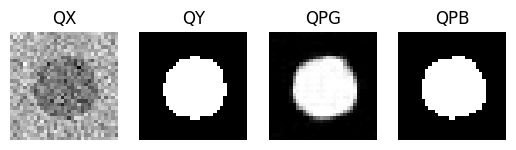

In [12]:
# unet-pred.py

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

bdDir = "."
outDir = "."
os.chdir(outDir)

nome = "077"
inImgX = nome + "x.png"
inImgY = nome + "y.png"

outImgG = nome + "g.png"
outImgB = nome + "b.png"

arquivoRede = "unet-train3.keras"   # ou unet-train2.keras

model = load_model(os.path.join(outDir, arquivoRede))

QX = cv2.imread(os.path.join(bdDir, inImgX), 0)
QY = cv2.imread(os.path.join(bdDir, inImgY), 0)

nl = QX.shape[0]
nc = QX.shape[1]

qx = np.float32(QX) / 255.0
qx = qx.reshape(1, nl, nc, 1)

qp = model.predict(qx, verbose=0)
qp = qp.reshape(nl, nc)

QPG = 255.0 * qp
QPG = np.clip(QPG, 0, 255)
QPG = np.uint8(QPG)
cv2.imwrite(os.path.join(outDir, outImgG), QPG)

QPB = np.zeros((nl, nc), dtype='uint8')
QPB[qp >= 0.5] = 255
cv2.imwrite(os.path.join(outDir, outImgB), QPB)

f = plt.figure()
f.add_subplot(1, 4, 1)
plt.imshow(QX, cmap="gray")
plt.axis('off')
plt.title("QX")

f.add_subplot(1, 4, 2)
plt.imshow(QY, cmap="gray")
plt.axis('off')
plt.title("QY")

f.add_subplot(1, 4, 3)
plt.imshow(QPG, cmap="gray")
plt.axis('off')
plt.title("QPG")

f.add_subplot(1, 4, 4)
plt.imshow(QPB, cmap="gray")
plt.axis('off')
plt.title("QPB")

plt.show(block=True)